# 04 — SHAP Analysis

Day 4 (plus its follow-up round): explain the trained model's predictions with SHAP
(SHapley Additive exPlanations) — which features push a given area's predicted heat up
or down, and by how much. See `DAY_4.md` for the concept explanation (what a Shapley
value actually is) and the full write-up, including why the model may now be trained at
SA1 resolution rather than SA2 (`03_model_training.ipynb` compares both and the better
one wins).

This notebook loads the saved `models/best_model.joblib` directly (and reads
`models/model_info.json` to know which resolution it was trained at), so what's
explained here is exactly the model that would be used downstream (e.g. in the Day 6/7
dashboard), not a separate copy. This notebook runs entirely locally against the
project's `.venv`. Select the **Python (urbancool-melbourne)** kernel in VS Code.

In [1]:
%matplotlib widget
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("Could not find project root (no pyproject.toml found in any parent)")


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: f:\personal_documents\Study\urbancool_melbourne\urbancool_melbourne


In [2]:
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from src.data.loaders import load_config
from src.models.train import FEATURE_COLS, TARGET_COL, load_model_data

warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "text.color": "#0b0b0b",
    "font.size": 10,
})

BLUE = "#2a78d6"
GREEN = "#008300"


## 1. Load the saved model and data

The saved pipeline (`models/best_model.joblib`) was **refit on all rows** (train + test,
at whichever resolution won the comparison in `03_model_training.ipynb`) using the
tuned hyperparameters — that notebook already answered "how well does this generalise to
unseen areas" with a proper held-out spatial test set, so there's no need to hold out
data again here. SHAP below explains this production model's behaviour across the full
population it was ultimately fit on.

In [3]:
import json as _json

config = load_config()
models_dir = PROJECT_ROOT / config["paths"]["models"]
model_info = _json.loads((models_dir / "model_info.json").read_text())
resolution = model_info["resolution"]
print("Winning resolution:", resolution, "| model:", model_info["model"], "| rows:", model_info["n_rows"])

model = joblib.load(models_dir / "best_model.joblib")
model_name = type(model.named_steps["model"]).__name__
print("Loaded pipeline steps:", list(model.named_steps.keys()))
print("Underlying model:", model_name)

data = load_model_data(resolution, config)
X = data[FEATURE_COLS]

# SHAP's TreeExplainer works on the raw tree model, not the sklearn Pipeline wrapper, so
# we replay the pipeline's own imputer (fit on the same data at training time) to get the
# exact matrix the model actually sees, then re-attach feature names for readable plots.
X_imputed = pd.DataFrame(model.named_steps["impute"].transform(X), columns=FEATURE_COLS, index=X.index)
X_imputed.shape

Winning resolution: SA1 | model: Random Forest | rows: 11017
Loaded pipeline steps: ['impute', 'model']
Underlying model: RandomForestRegressor


2026-07-09 18:52:36,047 INFO [SA1] Loaded 11487 rows, dropped 470 with no heat target -> 11017 modeling rows


(11017, 14)

If the winning model is a large, unrestricted-depth Random Forest (as SA1's is —
500 trees, `max_depth=None`), exact `TreeExplainer` computation is expensive: benchmarked
at ~0.6s/row for this specific model (500 rows took ~5 minutes), which would mean **~2
hours** for the full 11,017-row dataset. SHAP itself recommends explaining a
representative sample rather than every row for exactly this reason — the summary/
dependence patterns below are about understanding the model's general behaviour, not
auditing every individual prediction. A random sample of 300 rows keeps this notebook's
runtime to a few minutes while still giving a stable picture (SHAP's own examples
typically use samples in the low hundreds to low thousands).

In [4]:
SHAP_SAMPLE_SIZE = min(300, len(X_imputed))
X_shap = X_imputed.sample(n=SHAP_SAMPLE_SIZE, random_state=42)
print(f"Explaining a random sample of {len(X_shap)} of {len(X_imputed)} rows.")

Explaining a random sample of 300 of 11017 rows.


## 2. Compute SHAP values

`TreeExplainer` computes *exact* Shapley values for tree ensembles (no sampling
approximation needed, unlike the general-purpose `KernelExplainer`) by walking the trees'
decision paths directly — see `DAY_4.md` for what a Shapley value means. Each SA2 gets
one SHAP value per feature; they sum to that SA2's prediction minus the average
prediction across all SA2s.

In [5]:
explainer = shap.TreeExplainer(model.named_steps["model"])
explanation = explainer(X_shap)

print("shap values shape:", explanation.values.shape)
print("base value (average predicted UHI across the training population):", round(explanation.base_values[0], 3))
print("actual mean of predictions (full dataset):", round(model.predict(X).mean(), 3))

# Sanity check: base_value + sum(shap values) must reconstruct the underlying model's own
# prediction for every row in the sample, to float precision — if this fails, something is
# wrong with the setup above (e.g. explaining the wrong model, or a data mismatch).
reconstructed = explanation.base_values + explanation.values.sum(axis=1)
actual_preds_sample = model.named_steps["model"].predict(X_shap)
max_diff = np.abs(reconstructed - actual_preds_sample).max()
print("max |reconstructed - actual prediction| across the sample:", max_diff)
assert max_diff < 1e-6, "SHAP values do not reconstruct model predictions — explainer/data mismatch"


shap values shape: (300, 14)
base value (average predicted UHI across the training population): 8.538
actual mean of predictions (full dataset): 8.545
max |reconstructed - actual prediction| across the sample: 1.971756091734278e-13


## 3. Summary plot — which features matter, and which direction?

The classic SHAP beeswarm: each dot is one area from the 300-row sample (see the note
above section 1's data load). Position on the x-axis is that feature's SHAP
value (how much it pushed *this area's* prediction up or down from the average); dot
colour is the feature's own value (red = high, blue = low) using SHAP's standard colour
convention, not this project's chart palette — kept as-is since it's the widely
recognised default that SHAP users expect.

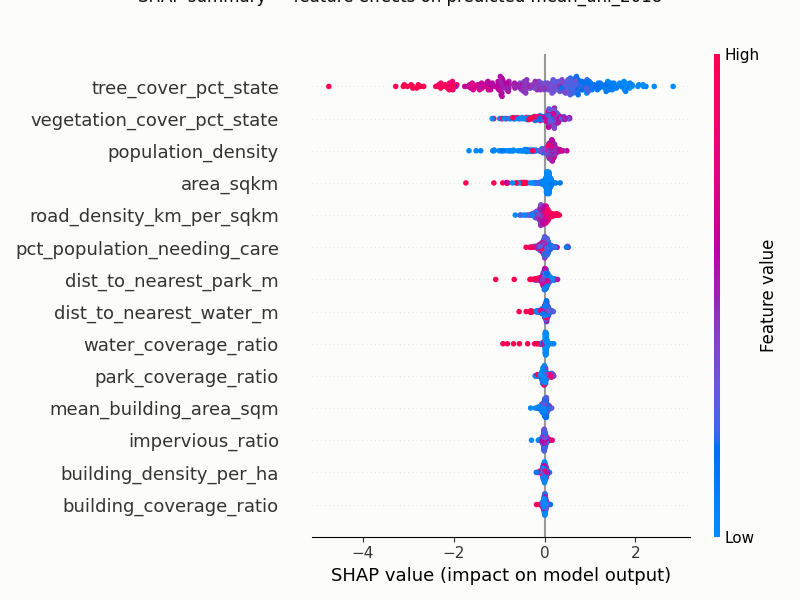

saved: f:\personal_documents\Study\urbancool_melbourne\urbancool_melbourne\models\shap_summary.png


In [6]:
shap.summary_plot(explanation, X_shap, show=False)
fig = plt.gcf()
fig.set_size_inches(8, 6)
fig.suptitle("SHAP summary — feature effects on predicted mean_uhi_2018", y=1.02)
fig.tight_layout()

models_dir = PROJECT_ROOT / config["paths"]["models"]
fig.savefig(models_dir / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved:", models_dir / "shap_summary.png")

## 4. Global importance — mean |SHAP value|

A bar-chart alternative to the beeswarm: average magnitude of each feature's effect,
ignoring direction. Compare this to the impurity-based `feature_importances_` bar chart
in `03_model_training.ipynb` section 7 — they're computed completely differently
(Shapley game-theoretic attribution vs. impurity reduction) but should broadly agree on
which features matter most, which is a useful cross-check.

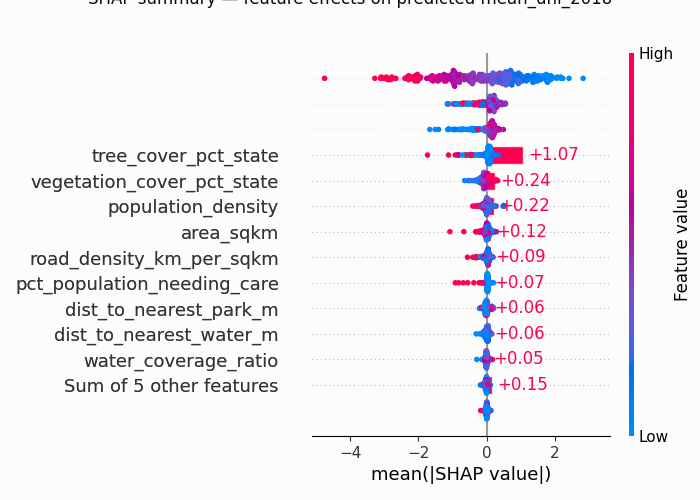

In [7]:
shap.plots.bar(explanation, show=False)
fig = plt.gcf()
fig.set_size_inches(7, 5)
fig.tight_layout()
plt.show()

In [8]:
mean_abs_shap = pd.DataFrame({
    "feature": FEATURE_COLS,
    "mean_abs_shap": np.abs(explanation.values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

impurity_importance = pd.read_csv(models_dir / "feature_importance.csv").rename(columns={"importance": "impurity_importance"})

comparison = mean_abs_shap.merge(impurity_importance, on="feature")
comparison["shap_rank"] = comparison["mean_abs_shap"].rank(ascending=False).astype(int)
comparison["impurity_rank"] = comparison["impurity_importance"].rank(ascending=False).astype(int)
comparison.sort_values("shap_rank")

,feature,mean_abs_shap,impurity_importance,shap_rank,impurity_rank
0,tree_cover_pct_state,1.065177,0.444116,1,1
1,vegetation_cover_pct_state,0.241250,0.117490,2,2
2,population_density,0.218332,0.100602,3,3
3,area_sqkm,0.121451,0.066519,4,4
4,road_density_km_per_sqkm,0.094223,0.038030,5,7
5,pct_population_needing_care,0.070735,0.039091,6,5
6,dist_to_nearest_park_m,0.062713,0.030486,7,8
7,dist_to_nearest_water_m,0.060960,0.038099,8,6
8,water_coverage_ratio,0.047930,0.022085,9,11
9,park_coverage_ratio,0.042095,0.024922,10,9


## 5. Dependence plots — how does the effect change with the feature's value?

The summary plot shows *that* `tree_cover_pct_state` matters most; a dependence plot
shows *how* — is the cooling effect linear, or does it saturate? SHAP auto-picks a
colouring feature to reveal interactions; here we show the three highest-ranked features
from section 4.

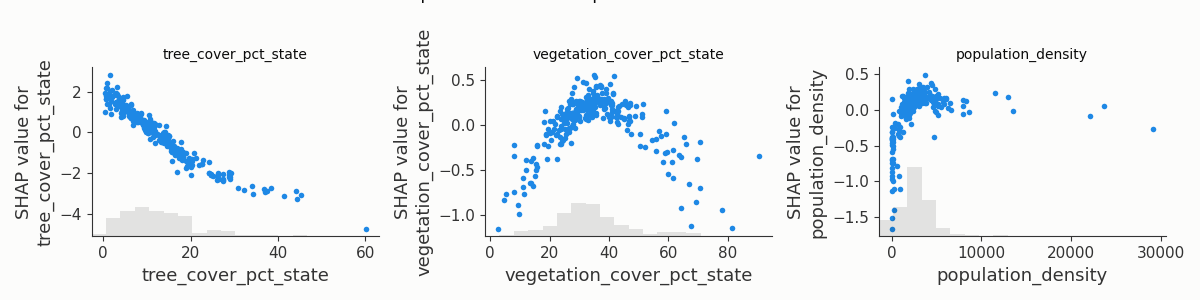

In [15]:
top_features = mean_abs_shap["feature"].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, feat in zip(axes, top_features):
    shap.plots.scatter(explanation[:, feat], ax=ax, show=False)
    ax.set_title(feat, fontsize=10)
fig.suptitle("SHAP dependence: effect on predicted UHI vs. feature value", y=1.05)
fig.tight_layout()
plt.show()

## 6. One prediction, explained

A waterfall plot for a single area — concretely showing how SHAP attributes an
individual prediction, not just the aggregate patterns above. Picked here: the single
highest predicted UHI **across the full dataset** (not just the 300-row sample — finding
the hottest prediction is a cheap `.predict()` call; only the SHAP *explanation* is
expensive, so this one row is explained individually rather than requiring it to have
been in the sample). Labelled by its parent SA2/suburb name — at SA1 resolution,
individual SA1 units aren't separately named, only grouped under their SA2.

Hottest predicted SA1 area: Cranbourne North - East (predicted 14.26 °C)


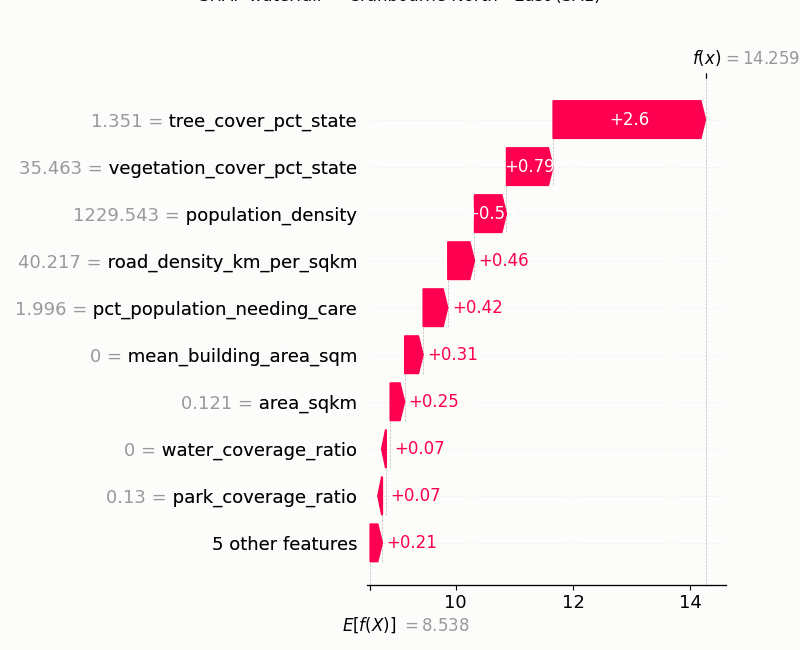

In [16]:
from matplotlib.pyplot import figure


all_preds = model.predict(X)
hottest_idx = all_preds.argmax()
hottest_name = data.iloc[hottest_idx]["SA2_NAME21"]
print(f"Hottest predicted {resolution} area: {hottest_name} (predicted {all_preds[hottest_idx]:.2f} °C)")

hottest_row = X_imputed.iloc[[hottest_idx]]
hottest_explanation = explainer(hottest_row)

figure(figsize=(10, 4))
shap.plots.waterfall(hottest_explanation[0], show=False)
fig = plt.gcf()
fig.suptitle(f"SHAP waterfall — {hottest_name} ({resolution})", y=1.02)
fig.tight_layout()
plt.show()

## Takeaways

- **The SHAP values exactly reconstruct the model's predictions** (section 2's assertion
  passed) — confirms the explainer is wired up correctly against this specific saved
  model, not silently explaining a different one.
- **Vegetation dominates**: `tree_cover_pct_state` and `vegetation_cover_pct_state`
  together account for the large majority of mean |SHAP value|, agreeing with both the
  impurity-based feature importance in `03_model_training.ipynb` and the raw correlations
  in `02_feature_engineering.ipynb` — three independent methods pointing the same
  direction is a good sign the signal is real, not an artifact of one particular
  technique.
- **The dependence plot for `tree_cover_pct_state` shows a steep effect at low cover and
  a flatter one at high cover** — consistent with a saturating (non-linear) cooling
  effect, which is exactly the kind of relationship a linear model (Ridge) structurally
  cannot represent, explaining Ridge's weaker CV performance in `03_model_training.ipynb`.
- **`population_density`** (new this round, only meaningful at SA1 resolution — see
  `03_model_training.ipynb`) shows up here too if the SA1 model won; check its SHAP rank
  in section 4's comparison table against its impurity-based rank.
- `models/shap_summary.png` is saved as the deliverable PNG per the project guide.

See `DAY_4.md` for the conceptual explanation of Shapley values and the full write-up.